###**Sparse Autoencoder for CIFAR-10**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load and Preprocess CIFAR-10 Dataset
# Transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

# Load dataset
trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Data loaders
train_loader = torch.utils.data.DataLoader(
    trainset,
    batch_size=128,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    testset,
    batch_size=128,
    shuffle=False
)

100%|██████████| 170M/170M [00:05<00:00, 29.1MB/s]


####1. Define Sparse Autoencoder Model

In [3]:
# Input dimension changed from 784 → 3072
class SparseAutoencoder(nn.Module):

    def __init__(self, input_size=3072, hidden_size=512):
        super(SparseAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 1024),
            nn.ReLU(),
            nn.Linear(1024, hidden_size),
            nn.Sigmoid()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(hidden_size, 1024),
            nn.ReLU(),
            nn.Linear(1024, input_size),
            nn.Tanh()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

####2. Sparsity Penalty (KL Divergence)

In [4]:
def sparsity_penalty(rho, rho_hat):

    rho_hat = torch.mean(rho_hat, dim=0)

    kl = rho * torch.log(rho / rho_hat) + \
         (1 - rho) * torch.log((1 - rho) / (1 - rho_hat))

    return torch.sum(kl)

####3. Initialize Model and Hyperparameters

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SparseAutoencoder().to(device)

criterion = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20

rho = 0.05        # desired sparsity
beta = 1e-3       # sparsity weight

####4.Training the Sparse Autoencoder

In [7]:
for epoch in range(epochs):

    total_loss = 0

    for images, _ in train_loader:

        images = images.view(images.size(0), -1).to(device)

        encoded, outputs = model(images)

        recon_loss = criterion(outputs, images)

        sparse_loss = sparsity_penalty(rho, encoded)

        loss = recon_loss + beta * sparse_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}")

Epoch [1/20], Loss: 0.0837
Epoch [2/20], Loss: 0.0584
Epoch [3/20], Loss: 0.0501
Epoch [4/20], Loss: 0.0447
Epoch [5/20], Loss: 0.0404
Epoch [6/20], Loss: 0.0371
Epoch [7/20], Loss: 0.0345
Epoch [8/20], Loss: 0.0324
Epoch [9/20], Loss: 0.0305
Epoch [10/20], Loss: 0.0293
Epoch [11/20], Loss: 0.0278
Epoch [12/20], Loss: 0.0268
Epoch [13/20], Loss: 0.0257
Epoch [14/20], Loss: 0.0248
Epoch [15/20], Loss: 0.0241
Epoch [16/20], Loss: 0.0235
Epoch [17/20], Loss: 0.0228
Epoch [18/20], Loss: 0.0222
Epoch [19/20], Loss: 0.0217
Epoch [20/20], Loss: 0.0210


5.Evaluate Reconstruction Loss

In [8]:
model.eval()

test_loss = 0

with torch.no_grad():

    for images, _ in test_loader:

        images = images.view(images.size(0), -1).to(device)

        encoded, outputs = model(images)

        loss = criterion(outputs, images)

        test_loss += loss.item()

print("Reconstruction Loss on Test Data:", test_loss/len(test_loader))

Reconstruction Loss on Test Data: 0.022125777682360216


6. Visualize Original vs Reconstructed Images

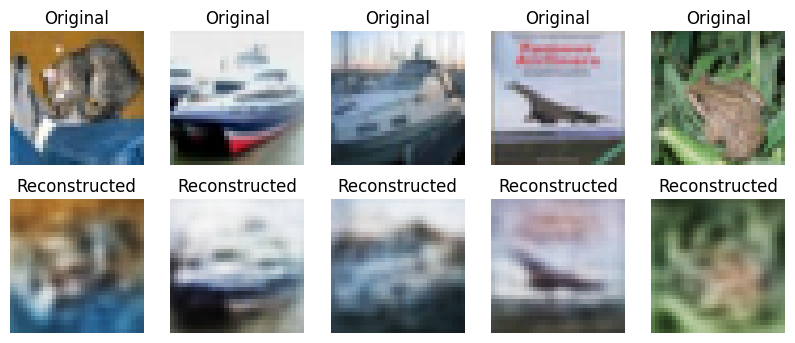

In [9]:
def imshow(img):

    img = img / 2 + 0.5
    npimg = img.numpy()

    plt.imshow(np.transpose(npimg, (1,2,0)))
    plt.axis('off')


dataiter = iter(test_loader)
images, _ = next(dataiter)

images_flat = images.view(images.size(0), -1).to(device)

encoded, outputs = model(images_flat)

outputs = outputs.view(-1,3,32,32).cpu()

# Plot comparison
plt.figure(figsize=(10,4))

for i in range(5):

    # Original
    plt.subplot(2,5,i+1)
    imshow(images[i])
    plt.title("Original")

    # Reconstructed
    plt.subplot(2,5,i+6)
    imshow(outputs[i].detach())
    plt.title("Reconstructed")

plt.show()

####**7. Experiment with Sparsity Values**

In [10]:
import matplotlib.pyplot as plt

# Different sparsity weights to experiment with
beta_values = [0, 1e-4, 1e-3, 1e-2]

epochs = 15
rho = 0.05

results = {}

for beta in beta_values:

    print("\nTraining with sparsity beta =", beta)

    model = SparseAutoencoder().to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_losses = []

    for epoch in range(epochs):

        total_loss = 0

        for images, _ in train_loader:

            images = images.view(images.size(0), -1).to(device)

            encoded, outputs = model(images)

            recon_loss = criterion(outputs, images)

            sparse_loss = sparsity_penalty(rho, encoded)

            loss = recon_loss + beta * sparse_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        epoch_loss = total_loss / len(train_loader)

        train_losses.append(epoch_loss)

        print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f}")

    results[beta] = {
        "model": model,
        "loss": train_losses
    }


Training with sparsity beta = 0
Epoch [1/15] Loss: 0.0770
Epoch [2/15] Loss: 0.0435
Epoch [3/15] Loss: 0.0356
Epoch [4/15] Loss: 0.0314
Epoch [5/15] Loss: 0.0289
Epoch [6/15] Loss: 0.0269
Epoch [7/15] Loss: 0.0254
Epoch [8/15] Loss: 0.0241
Epoch [9/15] Loss: 0.0230
Epoch [10/15] Loss: 0.0220
Epoch [11/15] Loss: 0.0211
Epoch [12/15] Loss: 0.0203
Epoch [13/15] Loss: 0.0197
Epoch [14/15] Loss: 0.0191
Epoch [15/15] Loss: 0.0184

Training with sparsity beta = 0.0001
Epoch [1/15] Loss: 0.0894
Epoch [2/15] Loss: 0.0539
Epoch [3/15] Loss: 0.0455
Epoch [4/15] Loss: 0.0402
Epoch [5/15] Loss: 0.0365
Epoch [6/15] Loss: 0.0339
Epoch [7/15] Loss: 0.0318
Epoch [8/15] Loss: 0.0300
Epoch [9/15] Loss: 0.0285
Epoch [10/15] Loss: 0.0271
Epoch [11/15] Loss: 0.0261
Epoch [12/15] Loss: 0.0250
Epoch [13/15] Loss: 0.0241
Epoch [14/15] Loss: 0.0234
Epoch [15/15] Loss: 0.0225

Training with sparsity beta = 0.001
Epoch [1/15] Loss: 0.1162
Epoch [2/15] Loss: 0.0632
Epoch [3/15] Loss: 0.0526
Epoch [4/15] Loss: 0.0

####**Plot Training Loss**

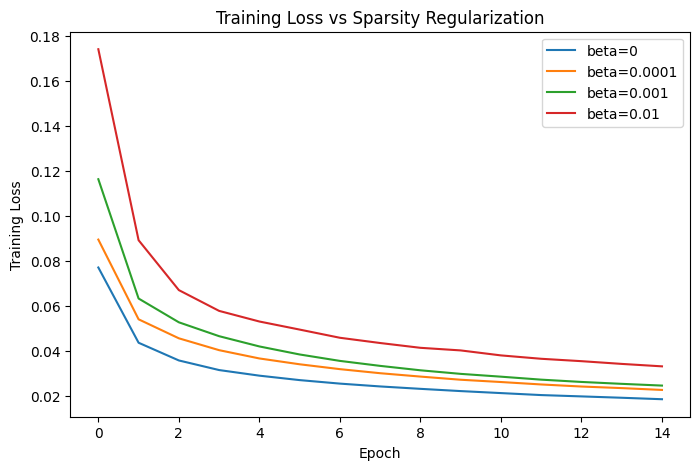

In [11]:
plt.figure(figsize=(8,5))

for beta in beta_values:
    plt.plot(results[beta]["loss"], label=f"beta={beta}")

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Sparsity Regularization")
plt.legend()
plt.show()

####**Evaluate Reconstruction using Mean Squared Error (MSE)**

In [12]:
for beta in beta_values:

    model = results[beta]["model"]

    model.eval()

    total_mse = 0
    total_samples = 0

    with torch.no_grad():

        for images, _ in test_loader:

            images = images.view(images.size(0), -1).to(device)

            encoded, outputs = model(images)

            # Compute batch MSE
            mse = torch.mean((images - outputs) ** 2)

            total_mse += mse.item()
            total_samples += 1

    avg_mse = total_mse / total_samples

    print(f"\nBeta = {beta}")
    print(f"Average Reconstruction MSE: {avg_mse:.6f}")


Beta = 0
Average Reconstruction MSE: 0.019234

Beta = 0.0001
Average Reconstruction MSE: 0.023389

Beta = 0.001
Average Reconstruction MSE: 0.025640

Beta = 0.01
Average Reconstruction MSE: 0.033478


The results show that reconstruction MSE increases as the sparsity regularization (β) increases. When β = 0, there is no sparsity constraint, so the model focuses only on reconstruction and achieves the lowest MSE (0.0192). As β increases (0.0001 → 0.01), the sparsity penalty forces fewer neurons to activate, which restricts the model’s capacity to reconstruct images accurately. Therefore, the reconstruction error gradually increases, indicating a trade-off between feature sparsity and reconstruction quality.

####**Visualize Reconstructions for Each Sparsity Value**

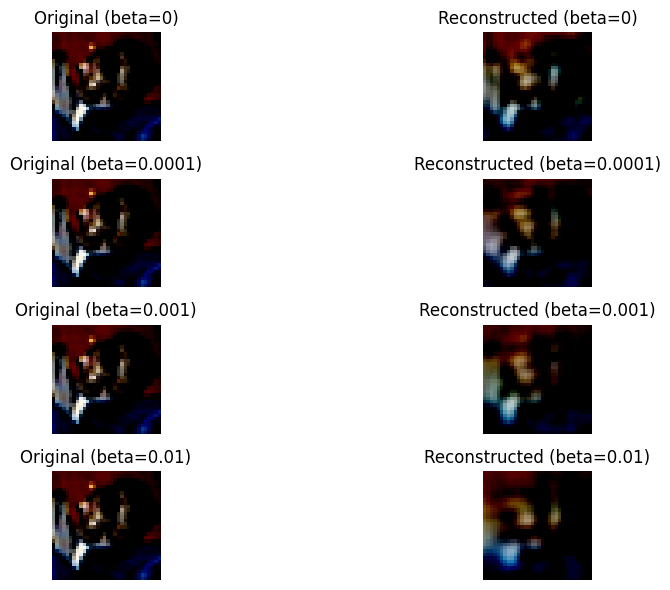

In [13]:
dataiter = iter(test_loader)
images, _ = next(dataiter)

images_flat = images.view(images.size(0), -1).to(device)

plt.figure(figsize=(12,6))

for i, beta in enumerate(beta_values):

    model = results[beta]["model"]

    with torch.no_grad():
        encoded, outputs = model(images_flat)

    outputs = outputs.view(-1,3,32,32).cpu()

    # original
    plt.subplot(len(beta_values),2,i*2+1)
    plt.imshow(images[0].permute(1,2,0))
    plt.title(f"Original (beta={beta})")
    plt.axis('off')

    # reconstructed
    plt.subplot(len(beta_values),2,i*2+2)
    plt.imshow(outputs[0].permute(1,2,0))
    plt.title(f"Reconstructed (beta={beta})")
    plt.axis('off')

plt.tight_layout()
plt.show()

The visualization shows that the reconstructed images become more distorted as the sparsity regularization (β) increases. When β = 0, the autoencoder focuses only on minimizing reconstruction error, resulting in relatively clearer reconstructed images. As β increases (0.0001 → 0.01), the sparsity constraint forces fewer neurons to activate in the hidden layer. This encourages the model to learn more compact feature representations, but it also reduces reconstruction quality, making the reconstructed images appear more blurred and less detailed. This demonstrates the trade-off between sparse feature learning and accurate image reconstruction.